current directory is:  G:\My Drive\didattica\CorsiGruppoBiofisica\LabBiofisLS\2026
size of the image= 3860 2178
Gating \ I0,J0 =  378 1346
Gating \ Dj,Di =  400 708
Rescale factor on the dx of the final image:  5.445 378 778 1346 2054
148321 400 708 321 19921
(321, 19921)
ratio of frequency range:  0.18341968911917098 0.18365472910927455


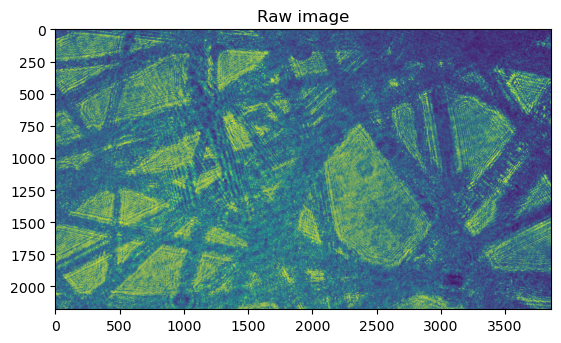

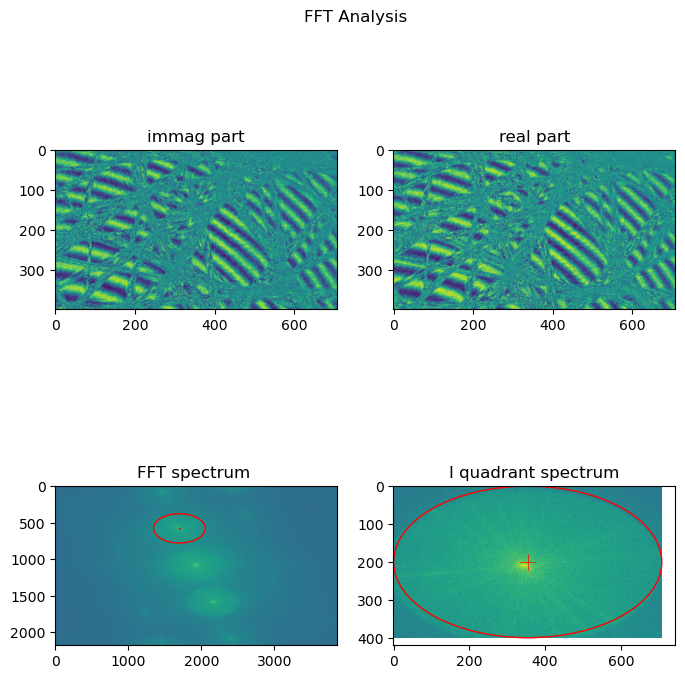

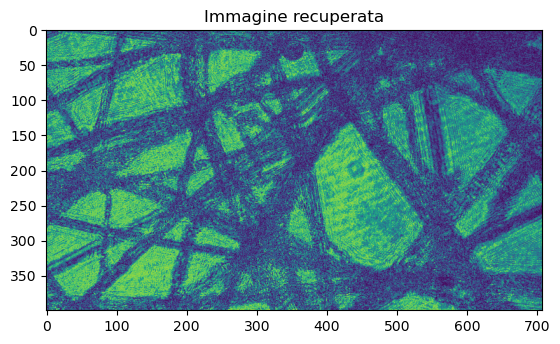

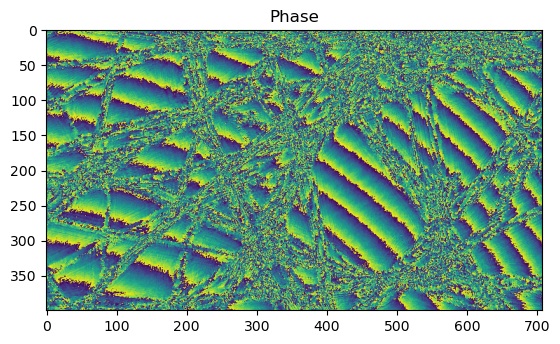

cartina_offaxis_2026_Phase.tiff
cartina_offaxis_2026_E_real.tiff
cartina_offaxis_2026_E_imag.tiff
cartina_offaxis_2026_I.tiff


In [17]:
# -*- coding: utf-8 -*-
"""
Created on Thu Mar  2 17:30:25 2023

@author: G
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cols
import math as mt
import matplotlib.gridspec as gridspec
from scipy import misc
import cmath as cm
from PIL import Image, ImageFilter
import os
import pandas as pd
from scipy import optimize as opt
import sys
from matplotlib.patches import Circle, Ellipse
import matplotlib.lines as lines


def StepPropagation(Ez0,freq,unni,freq0,k0,z):
    
############ propagate 2 #######################################################
    npix = Ez0.shape[0]
    GB_FT = np.fft.fft2(Ez0)
    #z = 1* z0
#FFy, FFx = np.mgrid[slice(fmin,fmax,df),slice(fmin,fmax,df)]
    FFy = np.outer(unni,freq)
    FFx = np.outer(freq,unni)

    PP = Propagator(k0,FFx,FFy,freq0,z)
    Ez = PP*GB_FT
    Ez = np.fft.ifft2(Ez)
#    Ezm = np.sqrt(Ez*np.conj(Ez))

    return Ez
#######################################################
def CircleMask(FFx,FFy,freq0):
    Mask = np.ones((FFx.shape))
    N = FFx.shape[0]
    f2 = freq0**2
    rr = FFx**2 + FFy**2
    for ii in range(N):
        for jj in range(N):
            if (rr[ii,jj]>f2):
                Mask[ii,jj] = 0
    return Mask
#######################################################
def Propagator(k0,FFx,FFy,freq0,z):
    Mask = CircleMask(FFx,FFy,freq0)
    Uni = np.ones((FFx.shape)) * k0*k0
    P = np.zeros((FFx.shape), dtype = 'complex')
#    print (P.shape)
    rr = FFx**2 + FFy**2
    N = FFx.shape[0]
    for ii in range (N):
        for jj in range(N):
            if Mask[ii,jj] == 1:
                P[ii,jj] = np.exp(-1j*z*np.sqrt( Uni[ii,jj] -4*np.pi*np.pi*rr[ii,jj] ))
    return P
 
#####################################################


path = "G:\\My Drive\\didattica\\CorsiGruppoBiofisica\\LabBiofisLS\\2026\\"
os.chdir(path)
path = os.getcwd() 
print ('current directory is: ',path)
fname = "cartina_offaxis_2026.tif"

Suff = fname.split('.')[0]
im = Image.open(fname)

plt.figure('Raw')
plt.imshow(im)
plt.title('Raw image')
Spettro = np.fft.fft2(im)
SpettroM = np.sqrt(Spettro*np.conj(Spettro))


# Create a figure and a grid of subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8)) #, gridspec_kw={'width_ratios': [4, 1], 'height_ratios': [1, 4]})
fig.suptitle('FFT Analysis') 
# Scatter plot in the center

axs[1,0].set_title('FFT spectrum ')
axs[1,0].imshow(np.log(np.fft.fftshift(SpettroM.real)))

nx,ny = im.size
print ('size of the image=',nx,ny)
#j0=int(ny/2)-250
#j1=int(nx/2)+350
###### selezione della parte di spettro 
DX = 400
i0 = 579 - int(DX/2)  #####rows 
i1 = i0 + DX
DY = int(DX*nx/ny)
j0 = 1700 - int( DY/2 )
j1 = j0 + DY
print ('Gating \\ I0,J0 = ',i0,j0)
print ('Gating \\ Dj,Di = ',DX,DY)
### draw the circle in the original full FFT spectrum
yCC = int(i0+DX/2)
xCC = int(j0+DY/2)
circL = Ellipse((xCC,yCC), DY, DX, color='red',fill=False)
axs[1,0].add_patch(circL)
axs[1,0].plot([xCC,xCC],[yCC-20,yCC+20],color='red',linewidth=0.5)
axs[1,0].plot([xCC-20,xCC+20],[yCC,yCC],color='red',linewidth=0.5)


print ('Rescale factor on the dx of the final image: ', ny/DX,i0,i1,j0,j1)
#plt.figure()
MatRecovery = np.fft.fftshift(SpettroM)[i0:i1,j0:j1]
#### find maximum
def trovaMax(Amat):
    dimx,dimy = Amat.shape
    Nmax = Amat.argmax()
    Imax = int(Nmax % dimx)
    Jmax = int(Nmax - Imax * dimx)
    print (Nmax,dimx,dimy,Imax,Jmax)
    
    return Imax,Jmax
print (trovaMax(MatRecovery))

axs[1,1].imshow(np.log(MatRecovery.real))
axs[1,1].set_title('I quadrant spectrum')

NRx,NRy = MatRecovery.shape
yCC = int(NRx/2)
xCC = int(NRy/2)
circL = Ellipse((xCC,yCC), NRy, NRx, color='red',fill=False)
axs[1,1].add_patch(circL)
axs[1,1].plot([xCC,xCC],[yCC-20,yCC+20],color='red',linewidth=0.5)
axs[1,1].plot([xCC-20,xCC+20],[yCC,yCC],color='red',linewidth=0.5)

Mat = np.fft.fftshift(np.fft.fftshift(Spettro)[i0:i1,j0:j1])
Im1 = np.fft.ifft2(Mat) #### this is the E field
Nx1 , Ny1 = Im1.shape

#### immagine recuperata
#plt.figure()
axs[0,1].set_title('real part')
axs[0,1].imshow(Im1.real) 
#plt.figure()
axs[0,0].imshow(Im1.imag) 
axs[0,0].set_title('immag part')
Im1m = np.sqrt(Im1*np.conj(Im1)).real
Phase = np.arctan2(Im1.imag,Im1.real)

plt.figure('rec Im')
plt.imshow(Im1m) 
plt.title('Immagine recuperata')


#plt.figure('retrieved Phase')
#fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 8))
plt.figure()
plt.title('Phase')
#ax[0].imshow(Phase)
plt.imshow(Phase)

npy,npx = Phase.shape
fraz = 0.5
#ax[1].plot(Phase[int(npx/2),int(npy/2)-int(fraz*npy/2):int(npy/2)+int(fraz*npy/2)])


print ('ratio of frequency range: ', npx/nx,npy/ny)
#ax.axis('off')
plt.show()

############# save  ###########
Im =Image.fromarray(Phase)
fout = Suff+'_Phase.tiff'
print (fout)
Im.save(fout)

fout = Suff+'_E_real.tiff'
Im =Image.fromarray(Im1.real)
Im.save(fout)
print (fout)

fout = Suff+'_E_imag.tiff'
Im =Image.fromarray(Im1.imag)
Im.save(fout)
print (fout)

fout = Suff+'_I.tiff'
Im =Image.fromarray(Im1m)
Im.save(fout)
print (fout)


propagate over  6  layers


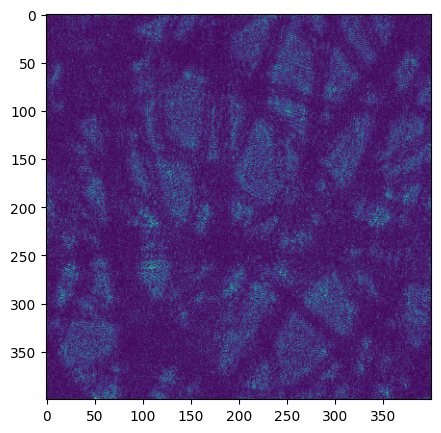

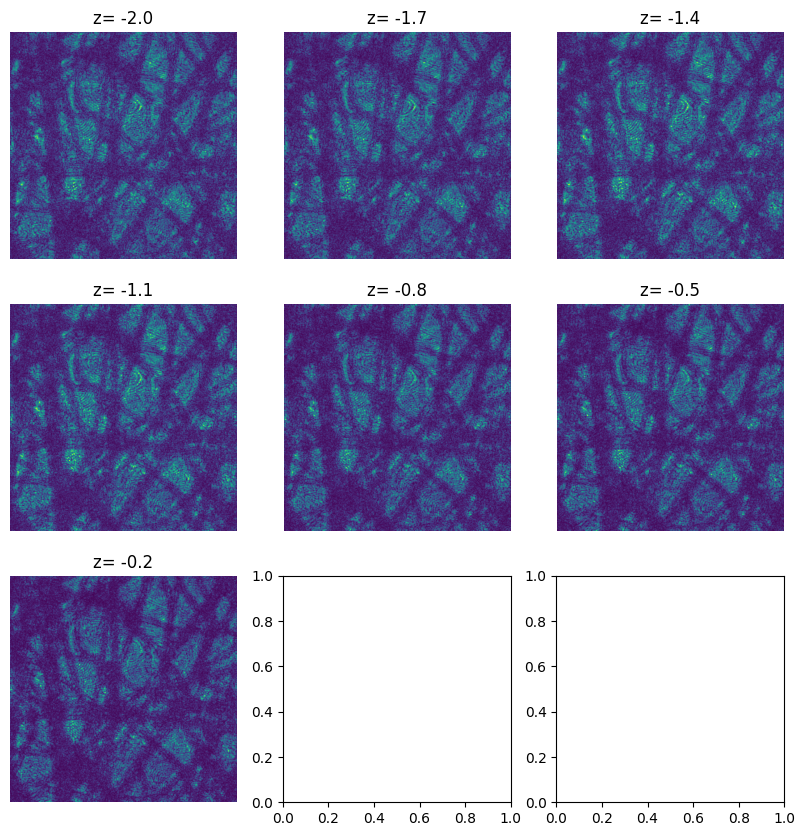

In [25]:
#### propagation
nx1,ny1 = Im1.shape
NX = np.min([nx1,ny1])
Im2 = Im1[0:NX,0:NX]

lam = 0.635 # um
k0 = 2*np.pi/lam
freq0 = 1/lam

dx = 0.2 ### um  TO BE CHECKED 
freq = np.fft.fftfreq(NX,dx)
unni = np.ones(freq.size)

Ez0 = Im2
plt.figure(1, figsize=(5,5))
plt.imshow(np.sqrt(Ez0.real*Ez0.real+Ez0.imag*Ez0.imag))

zin = -2.0
zfin = 0.0 
dz = 0.3
Nprop = int((zfin-zin)/dz)
print ('propagate over ',Nprop, ' layers') 
N2 = int(np.sqrt(Nprop))+1

Fig, Ax = plt.subplots(N2,N2, figsize = (10,10))

m = n = 0
for z in np.arange(zin,zfin,dz):
## um
    Ez= StepPropagation(Ez0,freq,unni,freq0,k0,z)
    mp = m% N2
    n= int(m/N2)

    Ax[n,mp].set_title('z= '+str(round(z,2)))
    Ax[n,mp].imshow(np.sqrt(Ez.real*Ez.real+Ez.imag*Ez.imag))
    Ax[n,mp].axis('off')
    m = m + 1
 


In [15]:
zin = -2.0
zfin = 4.0 
dz = 0.4 
Nprop = int((zfin-zin)/dz)
print ('propagate over ',Nprop, ' layers') 
N2 = int(np.sqrt(Nprop))+1
m = n = 0
for z in np.arange(-2,4,0.4):
    mp = m% N2
    print (round(z,2),m,mp,int(m/N2),N2,Nprop)
    m = m + 1
    

propagate over  15  layers
-2.0 0 0 0 4 15
-1.6 1 1 0 4 15
-1.2 2 2 0 4 15
-0.8 3 3 0 4 15
-0.4 4 0 1 4 15
-0.0 5 1 1 4 15
0.4 6 2 1 4 15
0.8 7 3 1 4 15
1.2 8 0 2 4 15
1.6 9 1 2 4 15
2.0 10 2 2 4 15
2.4 11 3 2 4 15
2.8 12 0 3 4 15
3.2 13 1 3 4 15
3.6 14 2 3 4 15
